# Video: Image Compression with Singular Value Decomposition

In this video, you will see singular value decomposition used to compress images with low rank approximations.

[![View on GitHub](https://img.shields.io/badge/GitHub-181717?logo=github&logoColor=white)](https://github.com/bu-cds-omds/dx601-examples/blob/main/week12/video_image_compression_with_singular_value_decomposition.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bu-cds-omds/dx601-examples/blob/main/week12/video_image_compression_with_singular_value_decomposition.ipynb)



Script:
* In this video, we will apply singular value decomposition to image compression by truncating their rank.

In [ ]:
import numpy as np
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import matplotlib.patches as patches

## Rhett at the Homecoming Parade, October 19, 1996.


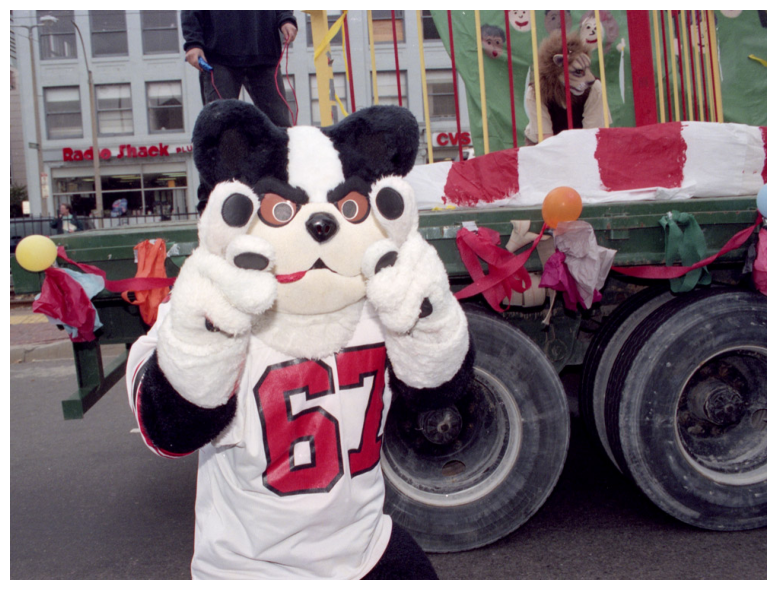

https://www.bu.edu/articles/2018/rhett-the-terrier-bu-mascot/


In [ ]:
# URL of the image
url = "https://www.bu.edu/files/2018/03/resized-96-3255A-032.jpg"

# Download the image
response = requests.get(url)
img_color = Image.open(BytesIO(response.content))

plt.figure(figsize=(12, 6))
plt.imshow(img_color)
plt.gca().axis('off')
plt.tight_layout()
plt.show()

print("https://www.bu.edu/articles/2018/rhett-the-terrier-bu-mascot/")

Script:
* I am going to use this picture of Rhett, the BU mascott, to show off SVD image compression.
* I found it on BU's web page for Rhett, and chose this particular one because I was out on Commonwealth Ave with Rhett that day.

## Data Dimensions

* Height: 750
* Width: 995
* Channels: 3

* Color shape: 750x995x3
* Grayscale shape: 750x995

Script:
* The raw image here is composed of a grid with 750 rows and 995 columns of colored pixels.
* Each pixel has 3 colors, red, green and blue.
* So, the color data fills an array with dimensions 750 by 995 by 3.
* To simplify this example, I'll just be compressing a one color grayscale version of the image, but you can use the same techniques on each color separately.

## Rhett in Grayscale


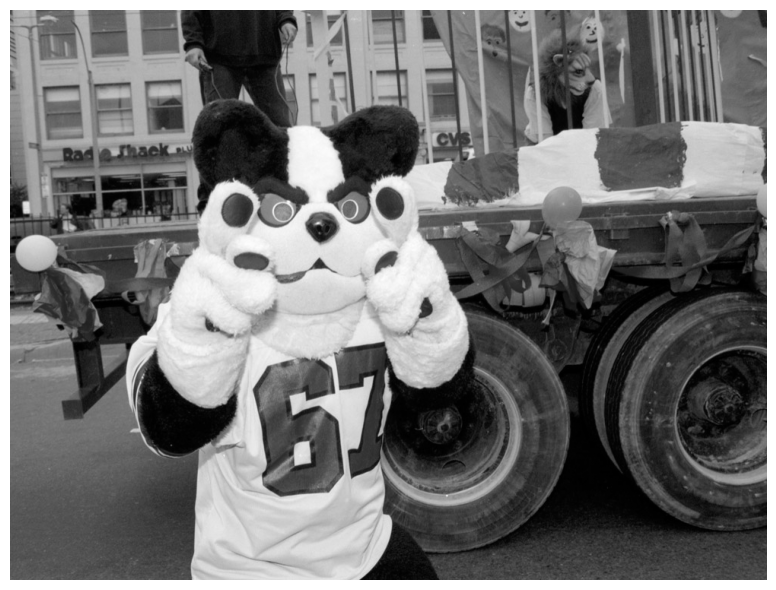

In [ ]:
img_gray = img_color.convert('L')

# Plot both images
plt.figure(figsize=(12, 6))
plt.imshow(img_gray, cmap='gray')
plt.gca().axis('off')
plt.tight_layout()
plt.show()

Script:
* Here's Rhett in grayscale.

In [ ]:
# Convert the grayscale image to a numpy array
img_array = np.array(img_gray)

U, s, Vt = np.linalg.svd(img_array)

## Singular Value Decomposition of the Image


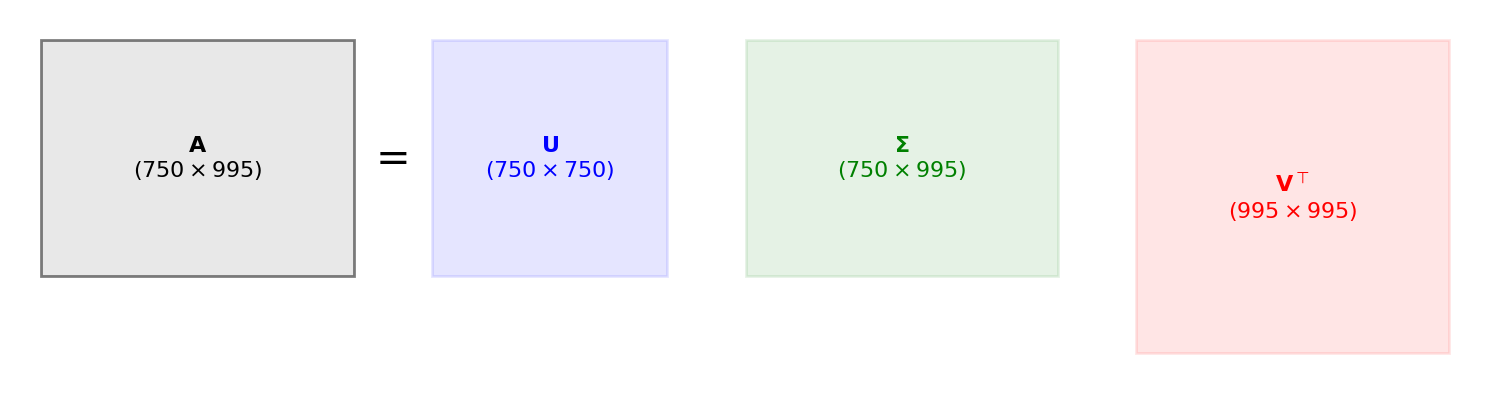

In [ ]:
# Get dimensions
m, n = img_array.shape

fig, ax = plt.subplots(figsize=(15, 6))

# Adjust spacing and positions to avoid overlap
gap = 250
x_a = 0
x_eq = n + gap/2
x_u = n + gap
x_s = x_u + m + gap
x_v = x_s + n + gap

y_center = m / 2

# 1. Matrix A (m x n)
rect_a = patches.Rectangle((x_a, 0), n, m, linewidth=2, edgecolor="black", facecolor="lightgray", alpha=0.5)
ax.add_patch(rect_a)
ax.text(x_a + n/2, y_center, f"$\\mathbf{{A}}$\n(${m} \\times {n}$)", ha="center", va="center", fontsize=16)

# Equals sign
ax.text(x_eq, y_center, "=", fontsize=30, ha="center", va="center")

# 2. Matrix U (m x m)
rect_u = patches.Rectangle((x_u, 0), m, m, linewidth=2, edgecolor="blue", facecolor="blue", alpha=0.1)
ax.add_patch(rect_u)
ax.text(x_u + m/2, y_center, f"$\\mathbf{{U}}$\n(${m} \\times {m}$)", ha="center", va="center", color="blue", fontsize=16)

# 3. Matrix Sigma (m x n)
rect_s = patches.Rectangle((x_s, 0), n, m, linewidth=2, edgecolor="green", facecolor="green", alpha=0.1)
ax.add_patch(rect_s)
ax.text(x_s + n/2, y_center, f"$\\mathbf{{\\Sigma}}$\n(${m} \\times {n}$)", ha="center", va="center", color="green", fontsize=16)
# ax.plot([x_s, x_s + min(m, n)], [m, m - min(m, n)], color="green", linestyle="--")

# 4. Matrix V^T (n x n) - Aligned to top edge
y_v = m - n
rect_vt = patches.Rectangle((x_v, y_v), n, n, linewidth=2, edgecolor="red", facecolor="red", alpha=0.1)
ax.add_patch(rect_vt)
ax.text(x_v + n/2, y_v + n/2, f"$\\mathbf{{V}}^\\top$\n(${n} \\times {n}$)", ha="center", va="center", color="red", fontsize=16)

# Formatting: Adjust y-limits to fit the lowest point (y_v) and highest point (m)
ax.set_xlim(-100, x_v + n + 100)
ax.set_ylim(min(0, y_v) - 100, m + 100)
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()
plt.show()

Script:
* The singular value decomposition of the image data will look like this.
* For now, I will focus on the shapes of these matrices rather than their contents.
* The shapes are more important for compression since they indicate how many numbers there are to be stored.
* The singular value decomposition by itself does not compress the data.
* Just the $\Sigma$ matrix takes the same space as the original data, which is why you will see libraries like NumPy just storing the diagonal of $\Sigma$ instead of the whole matrix.

## Truncated Singular Value Decomposition (t=250)


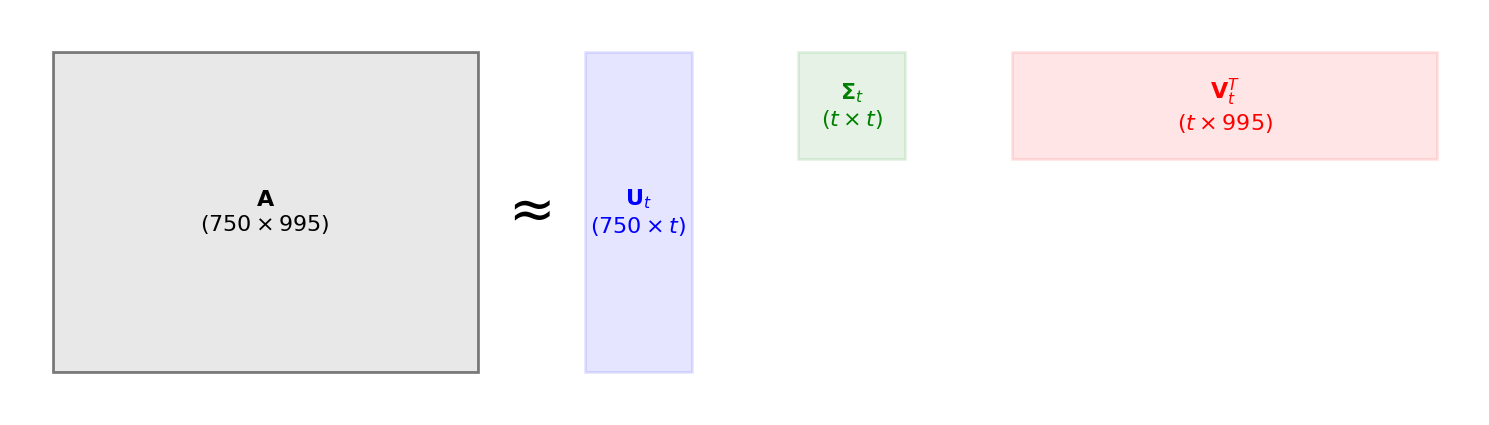

In [ ]:
# Get dimensions
m, n = img_array.shape
t = 250  # Truncated dimension for visualization

fig, ax = plt.subplots(figsize=(15, 6))

# Spacing and positions
gap = 250
x_a = 0
x_eq = n + gap/2
x_u = n + gap
x_s = x_u + t + gap
x_v = x_s + t + gap

y_center = m / 2

# 1. Matrix A (m x n)
rect_a = patches.Rectangle((x_a, 0), n, m, linewidth=2, edgecolor="black", facecolor="lightgray", alpha=0.5)
ax.add_patch(rect_a)
ax.text(x_a + n/2, y_center, f"$\\mathbf{{A}}$\n(${m} \\times {n}$)", ha="center", va="center", fontsize=16)

# Equals sign (approximation symbol typically used for truncated SVD)
ax.text(x_eq, y_center, "≈", fontsize=40, ha="center", va="center")

# 2. Matrix U_t (m x t)
rect_u = patches.Rectangle((x_u, 0), t, m, linewidth=2, edgecolor="blue", facecolor="blue", alpha=0.1)
ax.add_patch(rect_u)
ax.text(x_u + t/2, y_center, f"$\\mathbf{{U}}_t$\n(${m} \\times t$)", ha="center", va="center", color="blue", fontsize=16)

# 3. Matrix Sigma_t (t x t)
# Aligned to top edge (y = m - t)
y_s = m - t
rect_s = patches.Rectangle((x_s, y_s), t, t, linewidth=2, edgecolor="green", facecolor="green", alpha=0.1)
ax.add_patch(rect_s)
ax.text(x_s + t/2, y_s + t/2, "$\\mathbf{\\Sigma}_t$\n($t \\times t$)", ha="center", va="center", color="green", fontsize=16)
# ax.plot([x_s, x_s + t], [m, m - t], color="green", linestyle="--")

# 4. Matrix V_t^T (t x n)
# Aligned to top edge (y = m - t)
y_v = m - t
rect_vt = patches.Rectangle((x_v, y_v), n, t, linewidth=2, edgecolor="red", facecolor="red", alpha=0.1)
ax.add_patch(rect_vt)
ax.text(x_v + n/2, y_v + t/2, f"$\\mathbf{{V}}_t^T$\n($t \\times {n}$)", ha="center", va="center", color="red", fontsize=16)

# Formatting
ax.set_xlim(-100, x_v + n + 100)
ax.set_ylim(min(0, y_s, y_v) - 100, m + 100)
ax.set_aspect("equal")
ax.axis("off")
# plt.title(f"Truncated SVD Dimensions (t={t})", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

Script:
* The intuition behind compressing with singular value decompositions is that we can tactically shrink these matrices to get a product close to the original matrix.
* We will introduce a new parameter $t$ to control the number of rows and columns of $\Sigma$, and we will shrink $\mathbf{U}$ and $\mathbf{V}$ to match so that the dimensions work out for matrix multiplication.
* Note how that makes $\Sigma$ much smaller here, and both $\mathbf{U}$ and $\mathbf{V}$ get skinnier.
* Two details are crucial here.
* First, only the internal dimensions are shrinking, so the dimensions of the matrix multiplication are staying the same as the original data.
* Second, $\Sigma$ is sorted so the biggest singular values are first, so the biggest singular values are kept.
* If there are any zero signular values, those will be dropped first with no loss in reconstruction quality.
* Let's see how well it does.

## Reconstructing Rhett with Rank 20 SVD


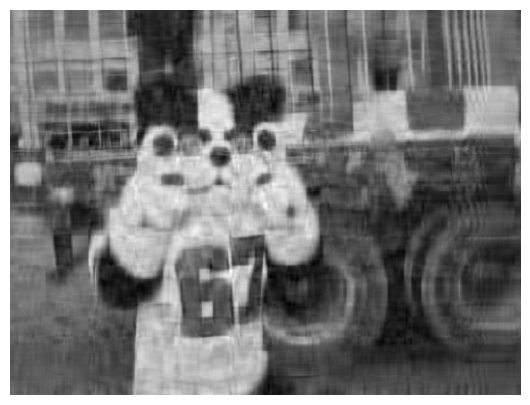

In [ ]:
def reconstruct_truncated_rank(t):
    U_t = U[:, :t]
    Sigma_t = np.diag(s[:t])
    Vt_t = Vt[:t, :]

    # Reconstruct the image by multiplying the truncated matrices
    return U_t @ Sigma_t @ Vt_t

def plot_truncated_rank(t, show_title=True):
    img_reconstructed = reconstruct_truncated_rank(t)

    # Plot the reconstructed image on the current active axes
    plt.imshow(img_reconstructed, cmap='gray')
    if show_title:
        plt.title(f"Rank {t}")
    plt.axis('off')

# Example: Reconstruct using rank 20 in a standalone figure
plt.figure(figsize=(8, 5))
plot_truncated_rank(20, show_title=False)
plt.show()

Script:
* Here is a reconstruction of Rhett with $\Sigma$ shrunk to a 20 by 20 matrix.
* Rhett is recognizable, but this is not a high quality image.
* But we can say that this is the best possible rank 20 matrix approximating the original image.
* Truncating the singular value decomposition to $t$ rows and columns will always give the best rank $t$ approximation as long as $\Sigma$ is sorted properly.

## Reconstructing Rhett with Rank 1 SVD


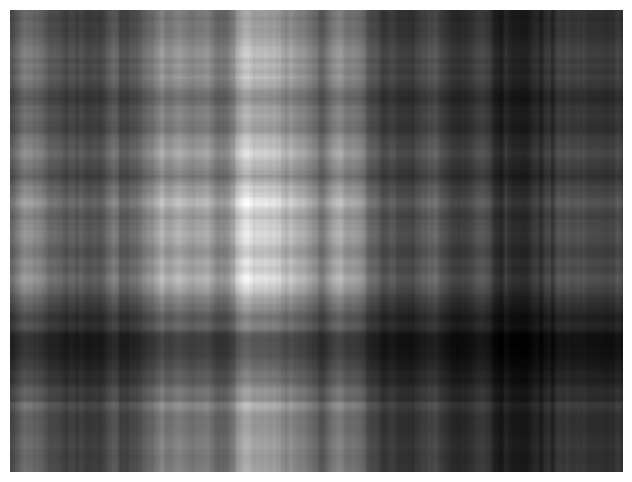

In [ ]:
plt.figure(figsize=(12, 6))
plot_truncated_rank(1, show_title=False)

Script:
* Here is the best rank 1 approximation.
* It is not recognizable at all.

## Reconstructing Rhett with Rank 100 SVD


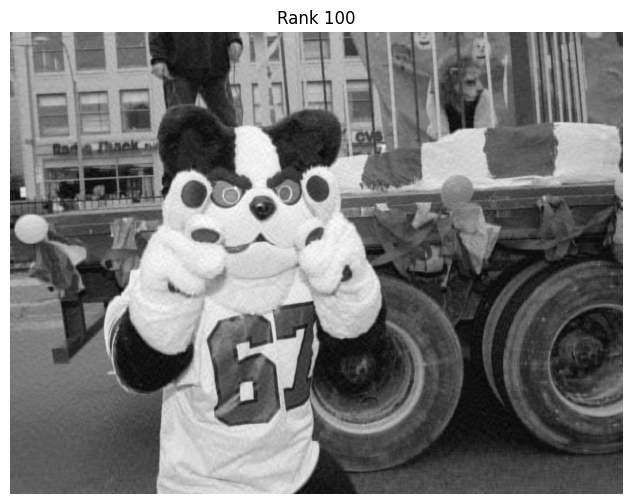

In [ ]:
plt.figure(figsize=(12, 6))
plot_truncated_rank(100, show_title=False)

Script:
* On the other hand, a rank 100 reconstruction looks fine to me.
* Maybe a bit grainy, but that might be the original image.

## Comparing Different Rank Reconstructions


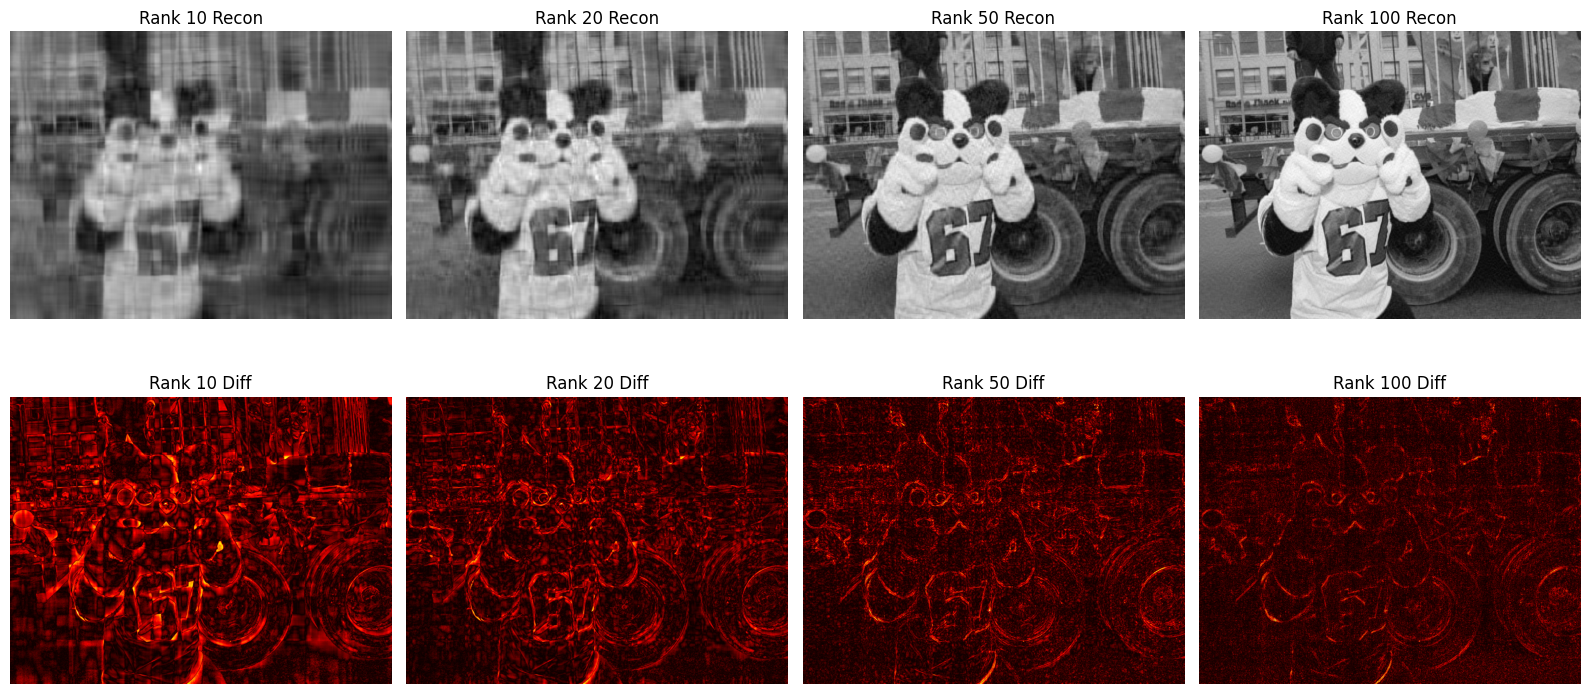

In [ ]:
plt.figure(figsize=(16, 8))

ranks = [10, 20, 50, 100]
for (i, rank) in enumerate(ranks):
    # Top row: Reconstructed image
    plt.subplot(2, 4, i + 1)
    reconstructed = reconstruct_truncated_rank(rank)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"Rank {rank} Recon")
    plt.axis('off')

    # Bottom row: Difference image
    plt.subplot(2, 4, i + 5)
    diff = np.abs(img_array - reconstructed)
    plt.imshow(diff, cmap='hot')
    plt.title(f"Rank {rank} Diff")
    plt.axis('off')

plt.tight_layout()
plt.show()

Script:
* If we look at several reconstuctions, and their differences from the original image, we can see the distortions fade as the rank increases.
* The differences become finer, and appear concentrated on sharper edges in the image.
* As the rank increases, these differences will completely disappear and the approximation will become perfect.

Script: (faculty on screen)
* Singular value decomposition gives a simple way to simplify complex data.
* Image compression with singular value decomposition will not give you state of the art results, but it is easy to understand using the linear algebra that you have learned so far.
